# **Лабораторна робота №3**
## “Кластеризація”
### Фролова Валерія КН-43

**Мета**: Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

In [20]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

## 1. Завантаження та підготовка даних
    a. Завантажити набір даних.
    b. Вивести перші кілька рядків і статистики колонок.
    c. Виконати стандартизацію числових ознак.
    d. Для зменшення кількості точок у візуалізації залишити лише треки з popularity ≥ 85. (Решту треків можна використати для навчання моделі, але візуалізувати лише популярні.)
    Вивести розмірність таблиці після фільтрації.


In [2]:
dataset_path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")
csv_file = next(f for f in os.listdir(dataset_path) if f.endswith('.csv'))
df = pd.read_csv(os.path.join(dataset_path, csv_file))
print(f"Розмірність датасету: {df.shape}")
df.head()

Розмірність датасету: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [5]:
audio_features = ['acousticness', 'danceability', 'duration_ms', 'energy', 
                  'instrumentalness', 'liveness', 'loudness', 'speechiness', 
                  'tempo', 'valence']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[audio_features] = scaler.fit_transform(df[audio_features])
df_top_tracks = df_scaled[df_scaled['popularity'] >= 85].copy()
print(f"Розмірність таблиці після фільтрації: {df_top_tracks.shape}")
df_top_tracks.head()

Розмірність таблиці після фільтрації: (417, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,-0.920210,0.924721,-0.375685,-0.064366,-0.489819,F,-0.549796,0.713529,Minor,-0.156670,1.693669,4/4,-0.461104
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.590358,0.919334,-0.474898,-0.948768,-0.489819,C#,-0.638563,-0.195745,Minor,1.090110,-1.538070,4/4,-0.522627
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,-0.201711,1.064802,-0.281340,-0.314884,-0.489788,F#,-0.612337,0.420108,Major,-0.270944,0.594664,4/4,0.300245
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,1.159745,0.499093,-0.534317,-0.994317,-0.489794,G,-0.065613,0.270396,Minor,-0.453676,-0.991027,4/4,-0.999431
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.232376,1.037863,-0.446648,-0.428755,-0.489819,F#,0.186565,0.446616,Major,0.982304,-1.379909,4/4,0.057998


## 2. Підбір оптимальної кількості кластерів (k) — метод ліктя
    a. Ініціалізувати модель KMeans із різною кількістю кластерів (наприклад k = 2…15).
    b. Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).
    c. Побудувати графік залежності інерції від k.
    d. Визначити оптимальне k.


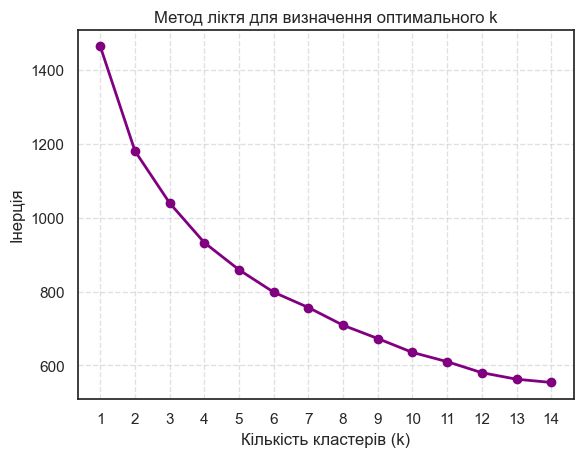

In [40]:
X = df_top_tracks[audio_features]

inertia_values = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='purple', linewidth=2, markersize=6)
plt.title('Метод ліктя для визначення оптимального k')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Побудова кластеризації
    a. Виконати кластеризацію з обраним значенням k.
    b. Додати отримані мітки кластерів до DataFrame як нову колонку cluster.
    c. Вивести кількість треків у кожному кластері.


In [27]:
optimal_k = 5 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df_top_tracks['cluster'] = kmeans.fit_predict(X)

cluster_counts = df_top_tracks['cluster'].value_counts().sort_index()
print(f"Кількість треків у кожному кластері:\n{cluster_counts}")
print("-" * 40)

print("Приклади пісень по кластерах:")
display(df_top_tracks[['artist_name', 'track_name', 'cluster']].head(10))

Кількість треків у кожному кластері:
cluster
0     75
1     72
2    130
3     92
4     48
Name: count, dtype: int64
----------------------------------------
Приклади пісень по кластерах:


,artist_name,track_name,cluster
9026,Ariana Grande,"break up with your girlfriend, i'm bored",3
9027,Ariana Grande,7 rings,4
9028,Halsey,Without Me,0
9029,Ariana Grande,needy,4
9030,Ariana Grande,NASA,4
9031,Ariana Grande,"thank u, next",2
9032,Ariana Grande,bloodline,0
9033,Ariana Grande,bad idea,0
9034,benny blanco,Eastside (with Halsey & Khalid),4
9035,Ariana Grande,fake smile,4


## 4.Візуалізація кластерів у просторі головних компонент
    a. Виконати PCA до двох/трьох компонент для візуалізації.
    b. Побудувати 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.


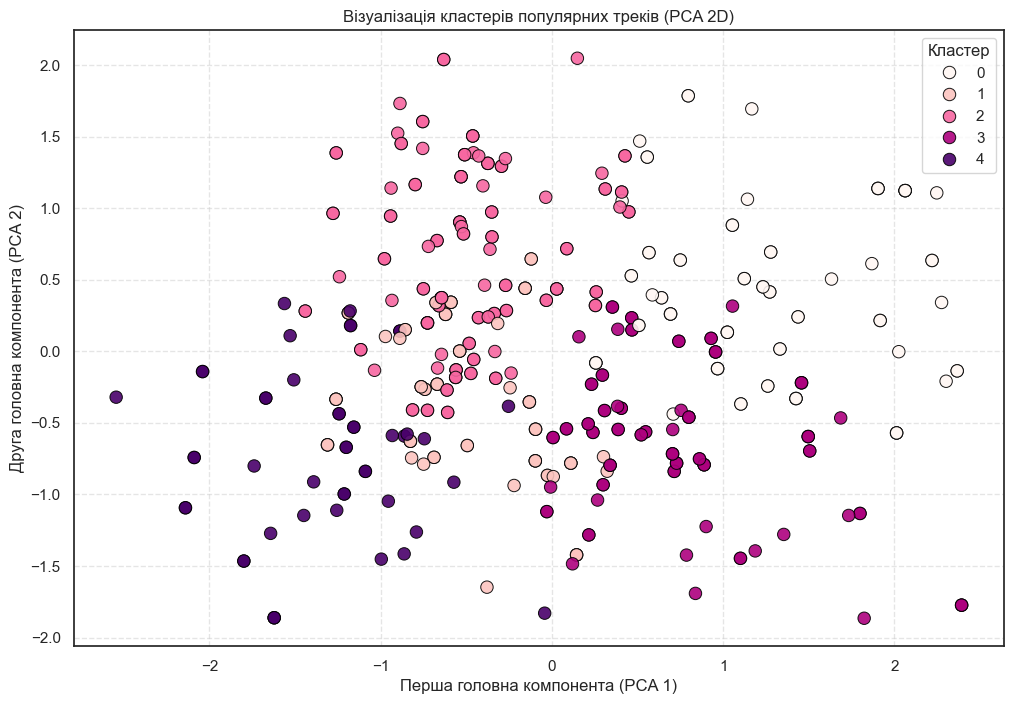

In [43]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X)

df_top_tracks['pca_1'] = pca_features[:, 0]
df_top_tracks['pca_2'] = pca_features[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='RdPu',
    data=df_top_tracks,
    s=80,
    alpha=0.9,
    edgecolor='black'
)

plt.title('Візуалізація кластерів популярних треків (PCA 2D)')
plt.xlabel('Перша головна компонента (PCA 1)')
plt.ylabel('Друга головна компонента (PCA 2)')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

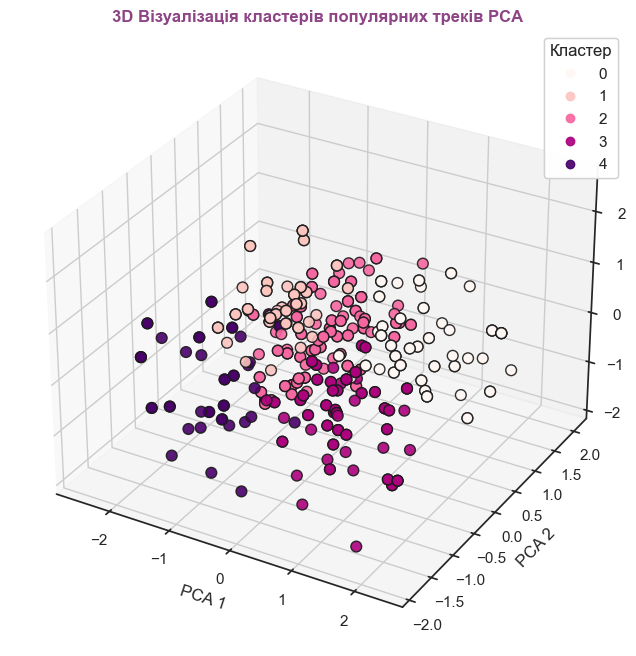

In [44]:
pca_3d = PCA(n_components=3, random_state=42)
pca_features_3d = pca_3d.fit_transform(X)

df_top_tracks['pca_1'] = pca_features_3d[:, 0]
df_top_tracks['pca_2'] = pca_features_3d[:, 1]
df_top_tracks['pca_3'] = pca_features_3d[:, 2]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_top_tracks['pca_1'], 
    df_top_tracks['pca_2'], 
    df_top_tracks['pca_3'], 
    c=df_top_tracks['cluster'], 
    cmap='RdPu', 
    s=60,          
    alpha=0.9,     
    edgecolor='k'
)

ax.set_title('3D Візуалізація кластерів популярних треків PCA', color='#8E4585', fontweight='bold')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

# Додаємо легенду
legend = ax.legend(*scatter.legend_elements(), title="Кластер")
ax.add_artist(legend)

plt.show()

## 5. Аналіз кластерів
    a. Для кожного кластера обчислити статистики основних ознак.
    b. Побудувати таблицю середніх значень основних ознак або графік (heatmap).
    c. Інтерпретувати кластери, наприклад:
        1. кластер 0 — енергійні танцювальні треки з високим темпом;
        2. кластер 1 — спокійні акустичні композиції;
        3. кластер 2 — експериментальні інструментальні треки тощо.


Середні значення ознак по кластерах:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,1.047633,0.405745,0.649717,0.228479,-0.762124,-0.484680,-0.244109,0.705272,1.258256,-0.258762
1,1.752557,-0.258686,0.283358,0.506466,-0.547397,-0.478156,-0.055113,-0.092232,-0.335818,-0.331752
2,0.765494,0.583095,0.816319,-0.169901,-0.447590,-0.488563,-0.394687,0.460619,-0.519791,-0.338341
3,0.608311,0.329810,0.621947,-0.198298,-0.565930,-0.482929,-0.062395,-0.556828,0.870198,-0.198100
4,0.326237,-0.423615,0.298130,0.100707,0.425490,-0.450808,-0.298101,-0.400534,-0.889462,-0.273801


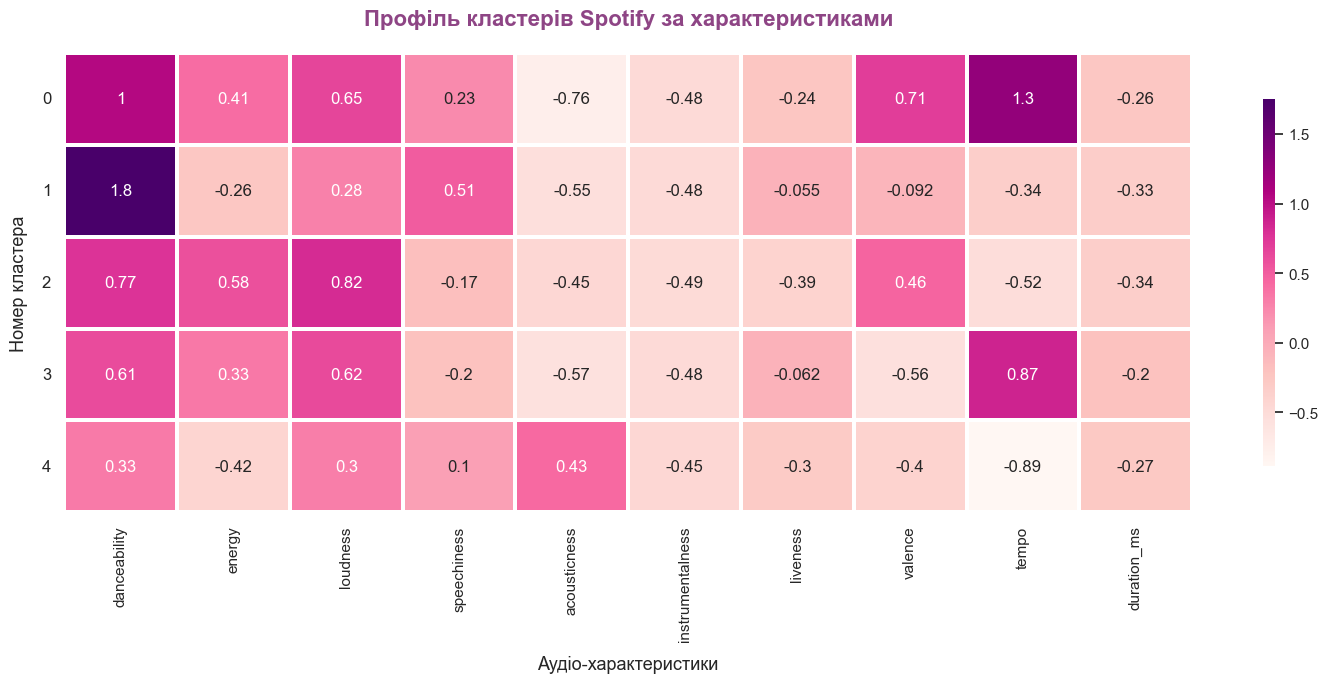

In [39]:
audio_features_ordered = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 
    'tempo', 'duration_ms'
]

sns.set_theme(style="white")

cluster_means = df_top_tracks.groupby('cluster')[audio_features_ordered].mean()

print("Середні значення ознак по кластерах:")
display(cluster_means)

plt.figure(figsize=(15, 7))
sns.heatmap(
    cluster_means, 
    cmap='RdPu',          
    annot=True,             
    fmt=".2g",             
    linewidths=1.5,         
    linecolor='white',      
    cbar_kws={"shrink": .8, "aspect": 30} 
)

plt.title('Профіль кластерів Spotify за характеристиками', fontsize=16, fontweight='bold', pad=20, color='#8E4585')
plt.xlabel('Аудіо-характеристики', fontsize=13, labelpad=10)
plt.ylabel('Номер кластера', fontsize=13, labelpad=10)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout() 
plt.show()

**Кластер 0 :**  (Швидкі позитивні хіти): Має найвищий показник темпу (tempo = 1.3), а також високі танцювальність (danceability = 1.0) та позитивність (valence = 0.71). Це дуже енергійні, життєрадісні танцювальні треки та поп-хіти.

**Кластер 1 :** (Хіп-хоп та реп): Яскраво виділяється максимальною танцювальністю (danceability = 1.8) та найбільшою кількістю тексту (speechiness = 0.51). Це типові реп-композиції з чітким бітом та великою кількістю слів.

**Кластер 2 :** (Гучні та драйвові треки): Відзначається найвищими показниками гучності (loudness = 0.82) та енергії (energy = 0.58). Це потужні, драйвові пісні, скоріш за все, електронна музика або енергійний поп-рок.

**Кластер 3 :**  (Динамічні, але мінорні пісні): Має високий темп (tempo = 0.87) і гучність, проте дуже низький показник позитивності (valence = -0.56). Це швидкі, але емоційно похмурі, серйозні або драматичні композиції.

**Кластер 4 :**  (Спокійна акустика): Єдиний кластер із додатнім показником акустичності (acousticness = 0.43) та найнижчими показниками темпу (tempo = -0.89) і енергії (energy = -0.42). Це повільні, ліричні композиціі, для розслаблення.

**Висновок :** Алгоритм K-Means успішно впорався із завданням сегментації музики. Виявлені кластери є логічними і добре описують реальні музичні стилі та настрої популярних пісень.